# -----------Oil Price Time Series Modelling and Forecasting-------

## Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error
from math import sqrt

## Load Dataset

In [3]:
df = pd.read_csv("oil_prices_2426.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.set_index('date', inplace=True)

df.head()

,price (dollars)
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


### Descriptive Statistics

In [22]:
df.describe()

,price (dollars)
count,500.000000
mean,75.873980
std,42.912398
min,16.480000
25%,35.372500
50%,64.290000
75%,111.572500
max,158.780000


## Time Series Plot

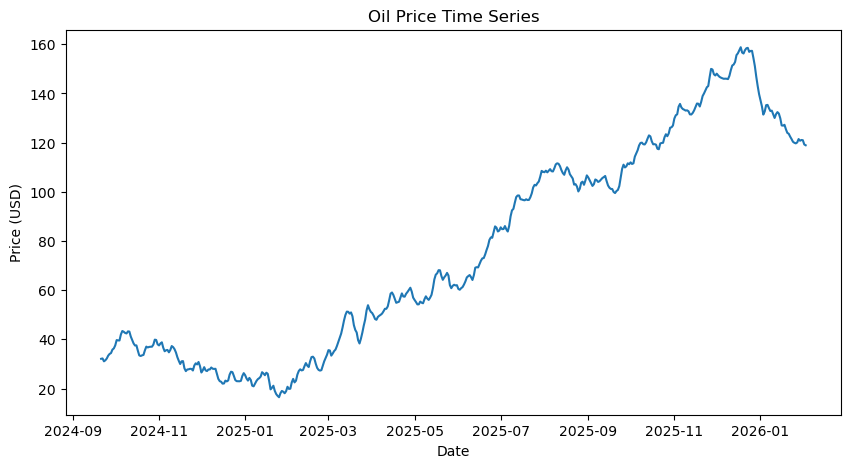

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df['price (dollars)'])
plt.title("Oil Price Time Series")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

## Stationarity Test (ADF)

In [5]:
result = adfuller(df['price (dollars)'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.5462340182601625
p-value: 0.882674139740307


## ACF and PACF Plots

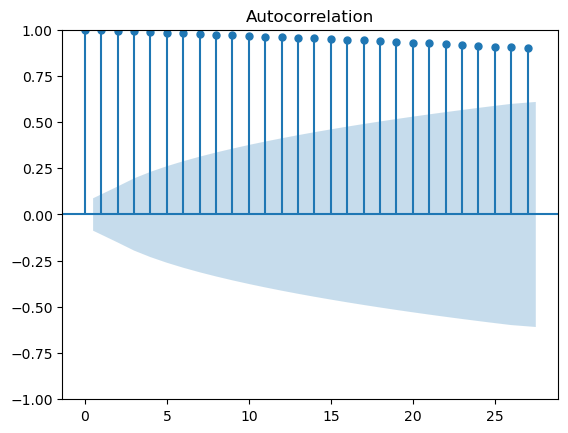

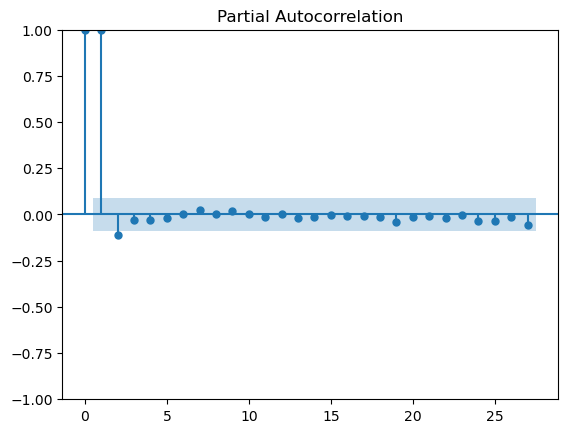

In [6]:
plot_acf(df['price (dollars)'])
plt.show()

plot_pacf(df['price (dollars)'])
plt.show()

## Differencing

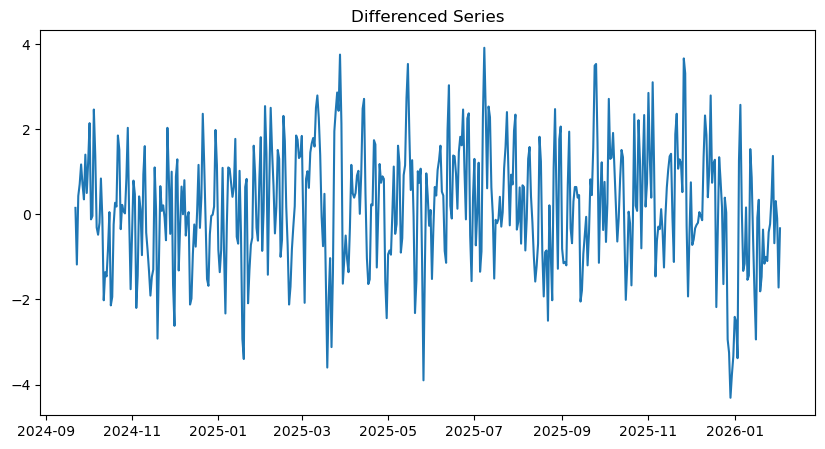

In [7]:
df_diff = df.diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(df_diff)
plt.title("Differenced Series")
plt.show()

## Train-Test Split

In [8]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

## ARMA Model Parameter Search

In [11]:
best_aic = np.inf
best_order = None
best_model = None

for p in range(0,9):
    for d in range(0,3):
        for q in range(0,9):
            try:
                model = ARIMA(train, order=(p,d,q))
                model_fit = model.fit()
                
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p,d,q)
                    best_model = model_fit
            except:
                continue

print("Best ARMA Order:", best_order)
print("Best AIC:", best_aic)

Best ARMA Order: (3, 2, 5)
Best AIC: 1125.7182292060866


## Residual Diagnostics

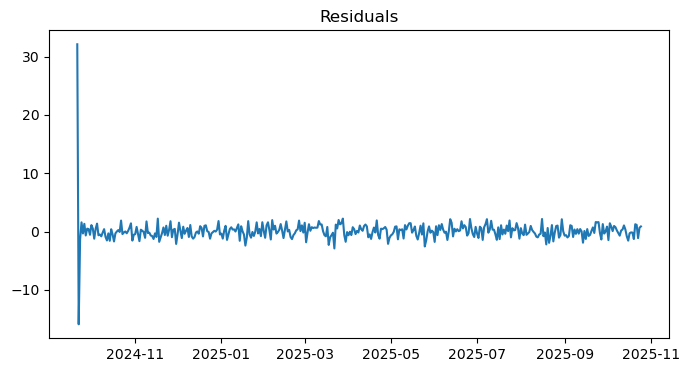

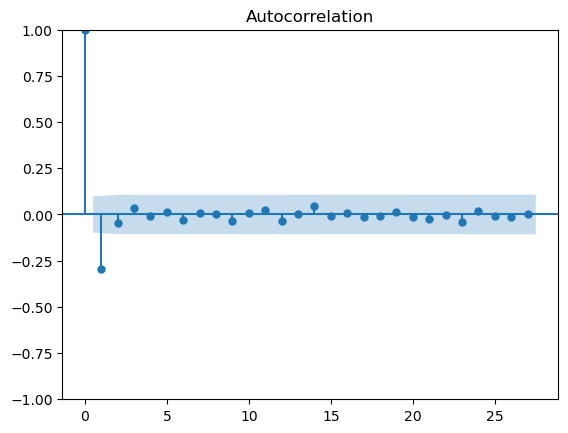

In [12]:
residuals = best_model.resid

plt.figure(figsize=(8,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plot_acf(residuals)
plt.show()

## Model Evaluation

In [13]:
predictions = best_model.forecast(steps=len(test))

rmse = sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 14.872917233557235


## Forecasting 24 Months Ahead

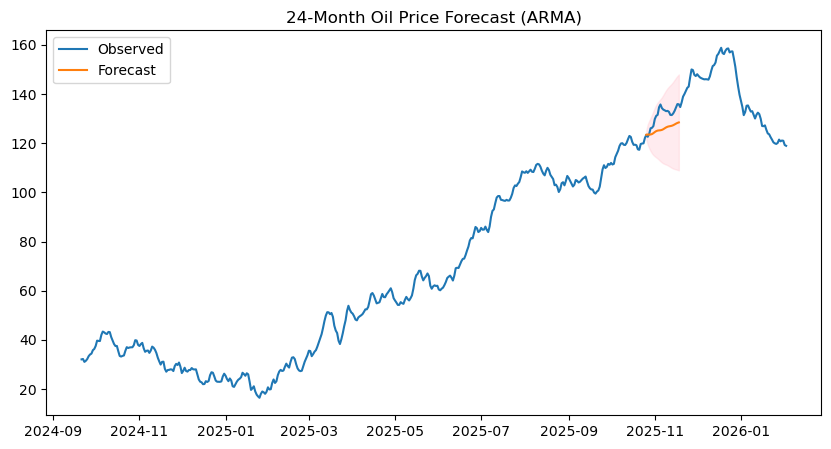

In [14]:
forecast = best_model.get_forecast(steps=24)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(10,5))
plt.plot(df, label='Observed')
plt.plot(forecast_mean, label='Forecast')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("24-Month Oil Price Forecast (ARMA)")
plt.show()

## Alternative Model: LSTM

In [15]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

### Data Preparation for LSTM

In [16]:
data = df['price (dollars)'].values.reshape(-1,1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [17]:
X = []
y = []

window = 10

for i in range(window, len(data_scaled)):
    X.append(data_scaled[i-window:i])
    y.append(data_scaled[i])

X = np.array(X)
y = np.array(y)

### LSTM Model

In [18]:
model = Sequential()

model.add(LSTM(50, activation='relu', input_shape=(X.shape[1],1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X, y, epochs=20, batch_size=16)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1607
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.4834e-04
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.3876e-04
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.7655e-04
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.4326e-04
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.4331e-04
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.0971e-04
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.4602e-04
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.8389e-04
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.3084e-04
Epoch 13/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.5391e-04
Epoch 14/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.8154e-04
Epoch 15/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s

### LSTM Prediction

In [19]:
pred_lstm = model.predict(X)

pred_lstm = scaler.inverse_transform(pred_lstm)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


### LSTM Model Evaluation

In [20]:
actual = scaler.inverse_transform(y)

rmse_lstm = sqrt(mean_squared_error(actual, pred_lstm))
print("LSTM RMSE:", rmse_lstm)

LSTM RMSE: 3.367770483285832


### Forecast Visualisation

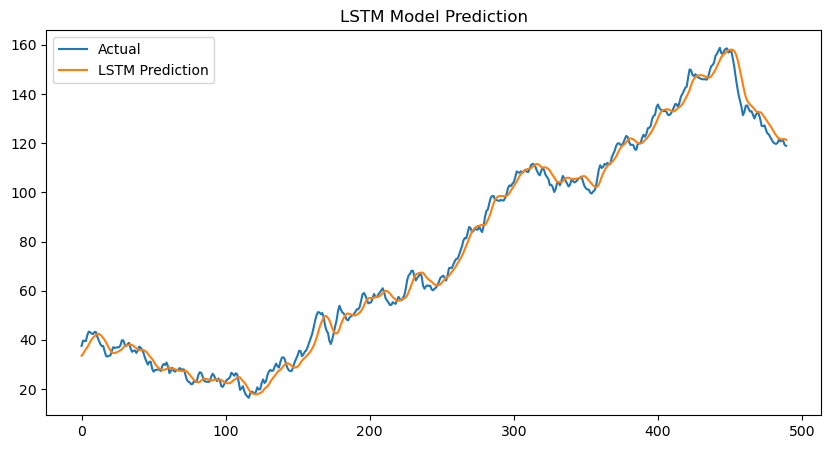

In [21]:
plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual")
plt.plot(pred_lstm, label="LSTM Prediction")

plt.title("LSTM Model Prediction")
plt.legend()

plt.show()

## Forecast 24 Months into the Future

In [23]:
future_steps = 24
last_window = data_scaled[-window:]

future_preds = []

for i in range(future_steps):
    
    pred = model.predict(last_window.reshape(1, window, 1))
    future_preds.append(pred[0,0])
    
    last_window = np.append(last_window[1:], pred)

future_preds = np.array(future_preds).reshape(-1,1)
future_preds = scaler.inverse_transform(future_preds)

print(future_preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[121.060974]
 [121.099144]
 [121.18249 ]
 [121.34036 ]
 [121.58801 ]
 [121.79655 ]
 [1

## Confidence Intervals

In [24]:
residuals = actual - pred_lstm

residual_std = np.std(residuals)

upper_ci = future_preds + 1.96 * residual_std
lower_ci = future_preds - 1.96 * residual_std

## Forecast Plot

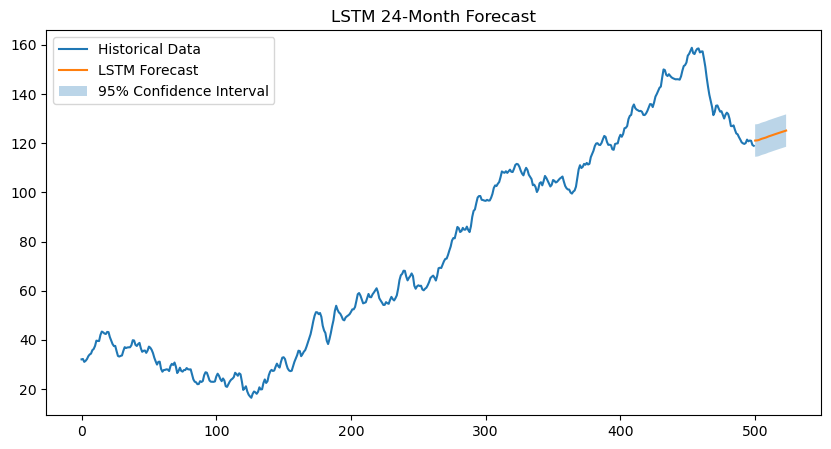

In [25]:
plt.figure(figsize=(10,5))

plt.plot(data, label="Historical Data")

future_index = range(len(data), len(data)+future_steps)

plt.plot(future_index, future_preds, label="LSTM Forecast")

plt.fill_between(future_index,
                 lower_ci.flatten(),
                 upper_ci.flatten(),
                 alpha=0.3,
                 label="95% Confidence Interval")

plt.title("LSTM 24-Month Forecast")
plt.legend()

plt.show()